# Import modules that need for this work

In [144]:
import numpy as np 
import matplotlib as plt 
import matplotlib.pyplot as plt
from sklearn import datasets 
from sklearn.model_selection import train_test_split 
from sklearn import svm 
from sklearn.svm import LinearSVC 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline 
from PlotClassification import plot_decision_regions 


# Get first 5 data frame frome the dataset 

In [145]:
import pandas as pd
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Take last 5 data frame


In [146]:
iris_df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


# Plot data before train of 3 type of Iris

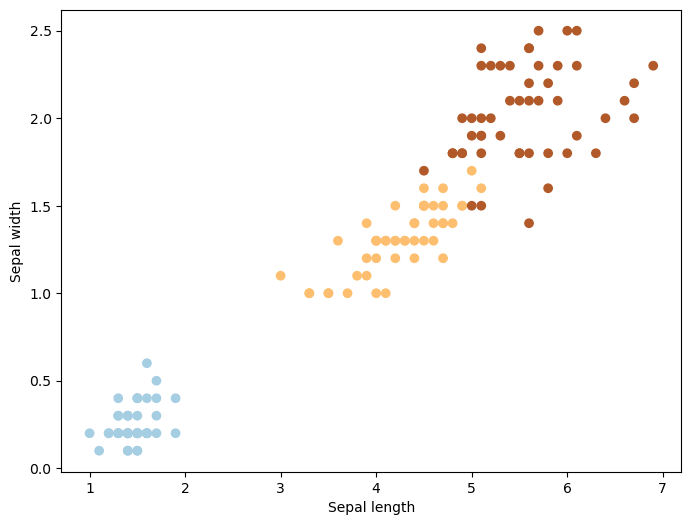

In [147]:
X = iris.data[:, (0,1)]  # take all the data rows and take last 2 columns 
Y = iris.target.astype(np.float64)  
plt.figure(2, figsize=(8, 6))
plt.clf()
# Plot data before train 
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.show()


# Begin training data 

In [148]:

# Split data into 70% training and 30% testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)
# Standardizing features 
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

# Build a Linear SVM classifier
svm_clf = LinearSVC( C = 10, loss = "hinge")
svm_clf.fit(X_train, Y_train)

# Test SVM model
Y_hat = svm_clf.predict(X_test)


c:\Users\pc\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [149]:
# scoring test
svm_clf.score(X_test, Y_test)

0.8222222222222222

In [150]:
# scoring train
svm_clf.score(X_train, Y_train)

0.9333333333333333

# Plot result after training 

c:\Users\pc\Documents\AI_Learning\Support_Vector_Machine\PlotClassification.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


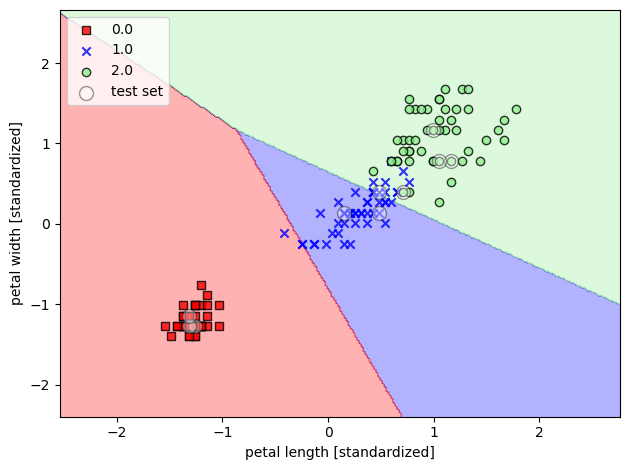

0.9

In [151]:
X_combined = np.vstack((X_train, X_test))
Y_combined = np.hstack((Y_train, Y_test))
plot_decision_regions(X_combined, Y_combined, classifier=svm_clf, test_idx=range(140, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
svm_clf.score(X_combined, Y_combined)